Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount("/content/drive_old", force_remount=True)

Mounted at /content/drive_old


In [ ]:
import os
from pathlib import Path

# Find which drive has the data
DRIVE_WITH_DATA = None
for d in ["/content/drive", "/content/drive_old"]:
    p = Path(f"{d}/MyDrive/ghostshot/data/processed")
    try:
        items = list(p.iterdir())
        if items:
            DRIVE_WITH_DATA = f"{d}/MyDrive/ghostshot"
            print(f"✅ Data found in: {d}")
            for item in items:
                print(f"    {item.name}")
            break
    except Exception as e:
        print(f"❌ {d}: {e}")

print(f"\nDRIVE_WITH_DATA = {DRIVE_WITH_DATA}")

❌ /content/drive: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive/ghostshot/data/processed'
✅ Data found in: /content/drive_old
    celebdf_real
    youtube_real
    celebdf_fake
    manifest.csv
    splits
    ghostshot_dataset.csv

DRIVE_WITH_DATA = /content/drive_old/MyDrive/ghostshot


In [ ]:
links = {
    f"{DRIVE_WITH_DATA}/data/raw":            "/content/ghostshot/data/raw",
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"\nReady. Device = {device}")

✅ raw
✅ processed
✅ attack_samples
✅ checkpoints
✅ results

Ready. Device = cuda


In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.7 MB/s eta 0:00:00


In [ ]:
import torch
import pandas as pd
from pathlib import Path
from src.models.classifier import GhostShotDetector
from src.models.losses import build_loss
from src.data.dataset import GhostShotDataset, get_val_transforms
from src.models.trainer import evaluate

# Find best checkpoint
ckpt_dir = Path("models/checkpoints")
ckpts = sorted(ckpt_dir.glob("*.pt"))
print("Available checkpoints:")
for c in ckpts:
    print(f"  {c.name}")

# Load best
best_ckpt = ckpts[-1]
print(f"\nLoading: {best_ckpt.name}")
ckpt = torch.load(str(best_ckpt), map_location=device, weights_only=False)
print(f"Epoch  : {ckpt['epoch']}")
print(f"Val AUC: {ckpt['val_auc']:.4f}")

Available checkpoints:
  ghostshot_best_epoch01_auc0.8172.pt
  ghostshot_best_epoch02_auc0.8309.pt
  ghostshot_best_epoch03_auc0.8394.pt
  ghostshot_best_epoch04_auc0.8443.pt
  ghostshot_best_epoch05_auc0.8497.pt
  ghostshot_best_epoch06_auc0.8554.pt
  ghostshot_best_epoch07_auc0.8564.pt
  ghostshot_best_epoch08_auc0.8587.pt
  ghostshot_best_epoch09_auc0.8603.pt
  ghostshot_best_epoch10_auc0.8616.pt

Loading: ghostshot_best_epoch10_auc0.8616.pt
Epoch  : 10
Val AUC: 0.8616


In [ ]:
import torch
import pandas as pd
from pathlib import Path
from src.data.dataset import GhostShotDataset, get_val_transforms
from src.models.trainer import evaluate

# Rebuild model
model = GhostShotDetector(
    num_classes    = cfg["data"]["num_classes"],
    pretrained     = False,  # no need to download weights
    use_fft_branch = cfg["model"]["use_fft_branch"],
    dropout        = cfg["model"]["dropout"],
).to(device)

# Load saved weights
model.load_state_dict(ckpt["model_state"])
model.eval()
print("✅ Model loaded from checkpoint!")

# Build test DataLoader
split_paths_small = {
    "test": Path("data/processed/splits/test_small.csv")
}

# Check if small csv exists, otherwise use full
if not split_paths_small["test"].exists():
    split_paths_small["test"] = Path("data/processed/splits/test.csv")

ds_test = GhostShotDataset(
    csv_path  = split_paths_small["test"],
    transform = get_val_transforms(cfg["data"]["img_size"])
)
loader_test = torch.utils.data.DataLoader(
    ds_test, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=True
)
print(f"✅ Test set: {len(ds_test)} samples")

# Build loss
criterion = build_loss(
    dataset_csv = Path("data/processed/splits/train_small.csv")
                  if Path("data/processed/splits/train_small.csv").exists()
                  else Path("data/processed/splits/train.csv"),
    cfg = cfg,
).to(device)

✅ Model loaded from checkpoint!
✅ Test set: 2136 samples
[loss] Class weights: [0.75 1.5 ]


In [ ]:
test_metrics = evaluate(model, loader_test, criterion, device, cfg)

print(f"\n── Test Results ──────────────────────────────────────")
print(f"  Test AUC : {test_metrics['auc']:.4f}")
print(f"  Test Acc : {test_metrics['acc']:.4f}")
print(f"  Test Loss: {test_metrics['loss']:.4f}")

/content/ghostshot/src/models/trainer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg["training"]["amp"]):



── Test Results ──────────────────────────────────────
  Test AUC : 0.8431
  Test Acc : 0.7659
  Test Loss: 0.1671


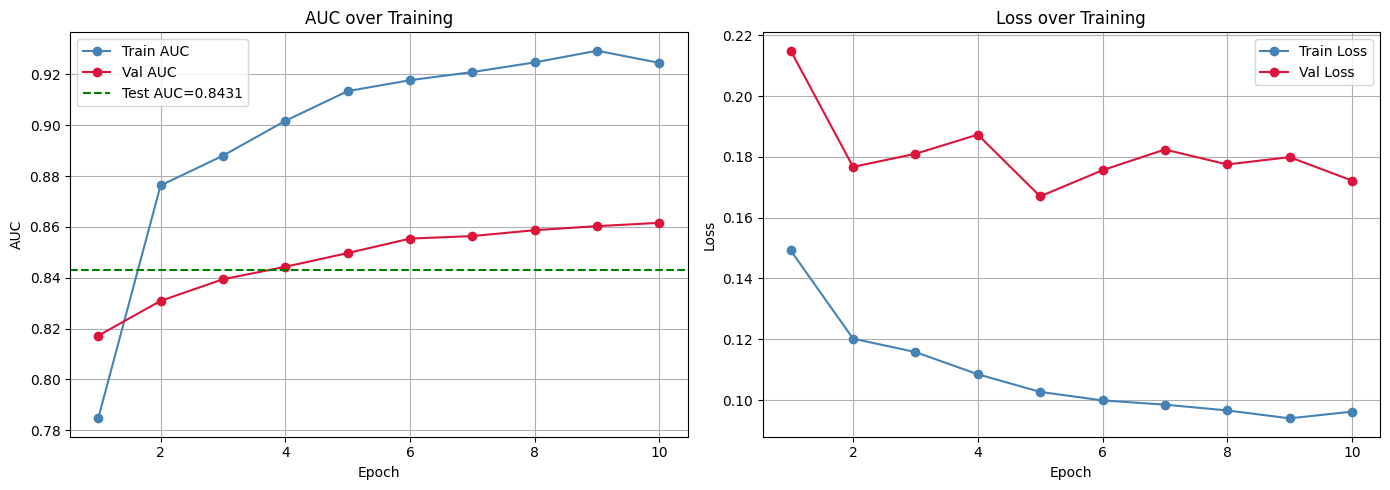

✅ Saved to results/figures/phase4_training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

epochs = list(range(1, 11))
train_auc = [0.7847, 0.8763, 0.8880, 0.9017, 0.9134, 0.9177, 0.9209, 0.9247, 0.9293, 0.9245]
val_auc   = [0.8172, 0.8309, 0.8394, 0.8443, 0.8497, 0.8554, 0.8564, 0.8587, 0.8603, 0.8616]
train_loss = [0.1492, 0.1202, 0.1158, 0.1085, 0.1027, 0.0999, 0.0985, 0.0966, 0.0940, 0.0962]
val_loss   = [0.2149, 0.1767, 0.1810, 0.1873, 0.1670, 0.1756, 0.1824, 0.1775, 0.1799, 0.1722]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_auc, marker="o", label="Train AUC", color="steelblue")
axes[0].plot(epochs, val_auc,   marker="o", label="Val AUC",   color="crimson")
axes[0].axhline(0.8431, color="green", linestyle="--", label=f"Test AUC=0.8431")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("AUC")
axes[0].set_title("AUC over Training")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, train_loss, marker="o", label="Train Loss", color="steelblue")
axes[1].plot(epochs, val_loss,   marker="o", label="Val Loss",   color="crimson")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss over Training")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/figures/phase4_training_curves.png", dpi=150)
plt.show()
print("✅ Saved to results/figures/phase4_training_curves.png")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

os.makedirs("results/figures", exist_ok=True)

# Get all predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loaders["test"]:
        images = batch["image"].to(device)
        labels = batch["label"]
        logits = model(images)
        preds  = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds  = np.vstack(all_preds)
all_labels = np.concatenate(all_labels)
pred_classes = all_preds.argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(all_labels, pred_classes)
print("── Confusion Matrix ──────────────────────────────────")
print(cm)

print("\n── Classification Report ─────────────────────────────")
print(classification_report(all_labels, pred_classes,
                             target_names=["Real", "Fake"]))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("GhostShot — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("results/figures/phase4_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved to results/figures/phase4_confusion_matrix.png")

NameError: name 'loaders' is not defined

In [ ]:
import pandas as pd
import torch
from pathlib import Path
from src.data.dataset import GhostShotDataset, get_val_transforms

# Build test DataLoader
test_path = Path("data/processed/splits/test_small.csv")
if not test_path.exists():
    test_path = Path("data/processed/splits/test.csv")

ds_test = GhostShotDataset(
    csv_path  = test_path,
    transform = get_val_transforms(cfg["data"]["img_size"])
)
loaders = {
    "test": torch.utils.data.DataLoader(
        ds_test, batch_size=32, shuffle=False,
        num_workers=2, pin_memory=True
    )
}
print(f"✅ Test set: {len(ds_test)} samples")

✅ Test set: 2136 samples


── Confusion Matrix ──────────────────────────────────
[[ 604  332]
 [ 146 1054]]

── Classification Report ─────────────────────────────
              precision    recall  f1-score   support

        Real       0.81      0.65      0.72       936
        Fake       0.76      0.88      0.82      1200

    accuracy                           0.78      2136
   macro avg       0.78      0.76      0.77      2136
weighted avg       0.78      0.78      0.77      2136



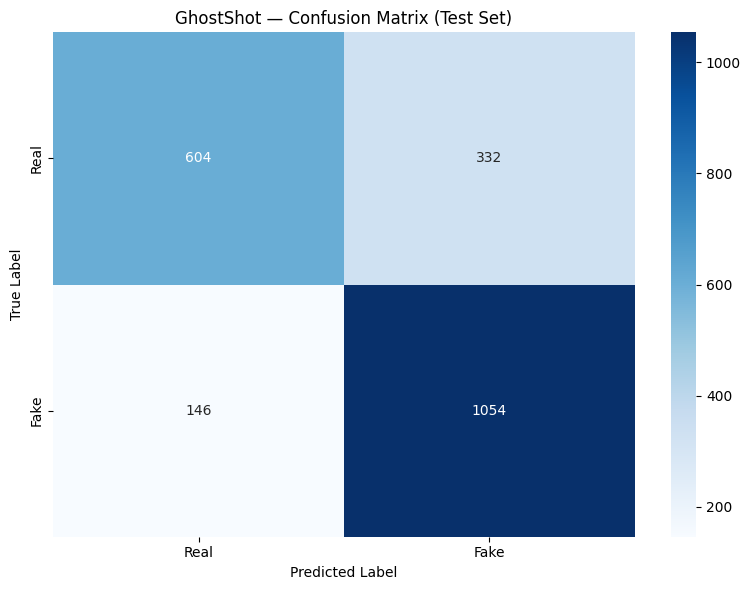

✅ Saved!


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

os.makedirs("results/figures", exist_ok=True)

# Get all predictions
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in loaders["test"]:
        images = batch["image"].to(device)
        labels = batch["label"]
        logits = model(images)
        preds  = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds    = np.vstack(all_preds)
all_labels   = np.concatenate(all_labels)
pred_classes = all_preds.argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(all_labels, pred_classes)
print("── Confusion Matrix ──────────────────────────────────")
print(cm)

print("\n── Classification Report ─────────────────────────────")
print(classification_report(all_labels, pred_classes,
                             target_names=["Real", "Fake"]))

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("GhostShot — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("results/figures/phase4_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved!")

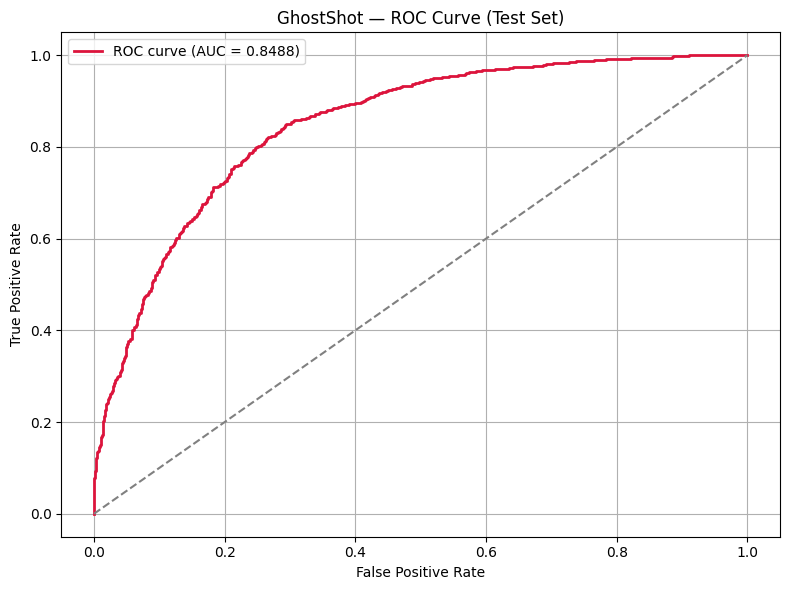

✅ ROC AUC = 0.8488


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_preds[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="crimson", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GhostShot — ROC Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/figures/phase4_roc_curve.png", dpi=150)
plt.show()
print(f"✅ ROC AUC = {roc_auc:.4f}")

In [ ]:
from google.colab import files
import os

figures = [
    "results/figures/phase4_training_curves.png",
    "results/figures/phase4_confusion_matrix.png",
    "results/figures/phase4_roc_curve.png",
    "results/figures/phase3_attack_results.png",
]

for fig in figures:
    if os.path.exists(fig):
        files.download(fig)
        print(f"✅ Downloaded: {fig}")
    else:
        print(f"❌ Not found: {fig}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: results/figures/phase4_training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: results/figures/phase4_roc_curve.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: results/figures/phase3_attack_results.png


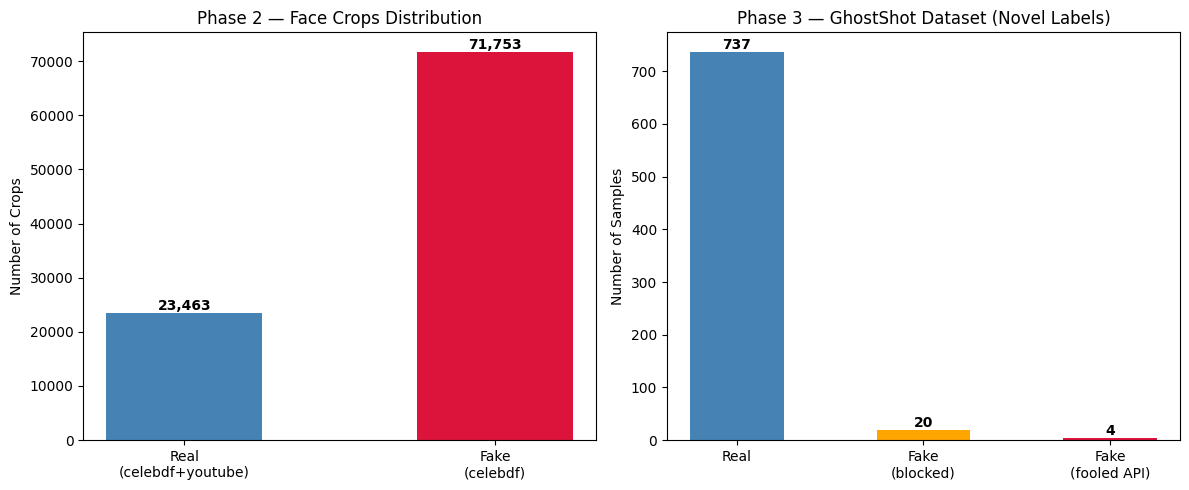

✅ Saved: dataset_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("results/figures", exist_ok=True)

# Figure 1 — Dataset distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Phase 2 dataset
labels   = ["Real\n(celebdf+youtube)", "Fake\n(celebdf)"]
counts   = [23463, 71753]
colors   = ["steelblue", "crimson"]
axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title("Phase 2 — Face Crops Distribution")
axes[0].set_ylabel("Number of Crops")
for i, v in enumerate(counts):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

# Phase 3 dataset
labels2  = ["Real", "Fake\n(blocked)", "Fake\n(fooled API)"]
counts2  = [737, 20, 4]
colors2  = ["steelblue", "orange", "crimson"]
axes[1].bar(labels2, counts2, color=colors2, width=0.5)
axes[1].set_title("Phase 3 — GhostShot Dataset (Novel Labels)")
axes[1].set_ylabel("Number of Samples")
for i, v in enumerate(counts2):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("results/figures/dataset_distribution.png", dpi=150)
plt.show()
print("✅ Saved: dataset_distribution.png")

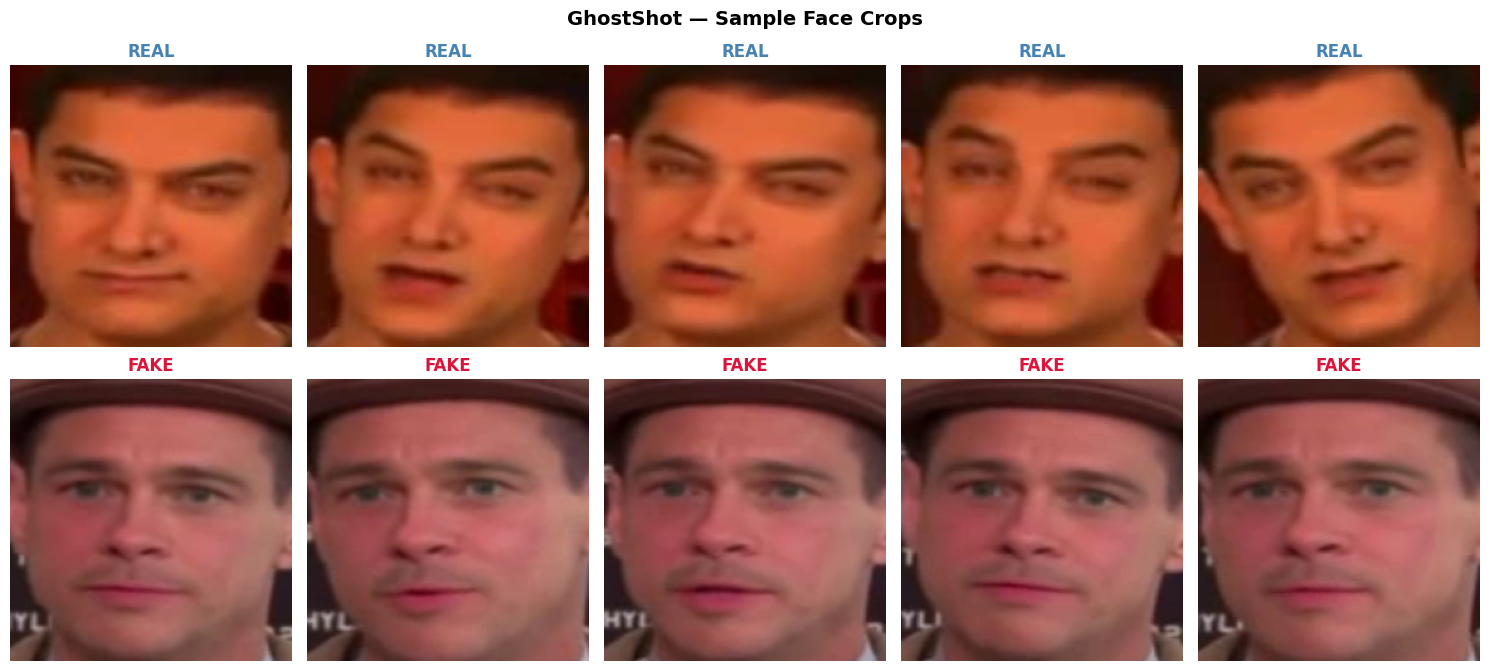

✅ Saved: sample_face_crops.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

random.seed(42)

# Get some real and fake crop paths
real_crops = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[:20]
fake_crops = list(Path("data/processed/celebdf_fake/1").rglob("*.png"))[:20]

random.shuffle(real_crops)
random.shuffle(fake_crops)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("GhostShot — Sample Face Crops", fontsize=14, fontweight="bold")

# Real faces
for i in range(5):
    img = cv2.imread(str(real_crops[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title("REAL", color="steelblue", fontweight="bold")
    axes[0, i].axis("off")

# Fake faces
for i in range(5):
    img = cv2.imread(str(fake_crops[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title("FAKE", color="crimson", fontweight="bold")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("results/figures/sample_face_crops.png", dpi=150)
plt.show()
print("✅ Saved: sample_face_crops.png")

In [ ]:
from google.colab import files
import os

figures = [
    "results/figures/phase4_training_curves.png",
    "results/figures/phase4_confusion_matrix.png",
    "results/figures/phase4_roc_curve.png",
    "results/figures/phase3_attack_results.png",
    "results/figures/dataset_distribution.png",
    "results/figures/sample_face_crops.png",
]

for fig in figures:
    if os.path.exists(fig):
        files.download(fig)
        print(f"✅ Downloaded: {fig.split('/')[-1]}")
    else:
        print(f"❌ Not found: {fig}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: phase4_training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: dataset_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: sample_face_crops.png


In [ ]:
from google.colab import files
import shutil

# Create ZIP
shutil.make_archive("all_figures", "zip", "results/figures")

# Download to your computer
files.download("all_figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

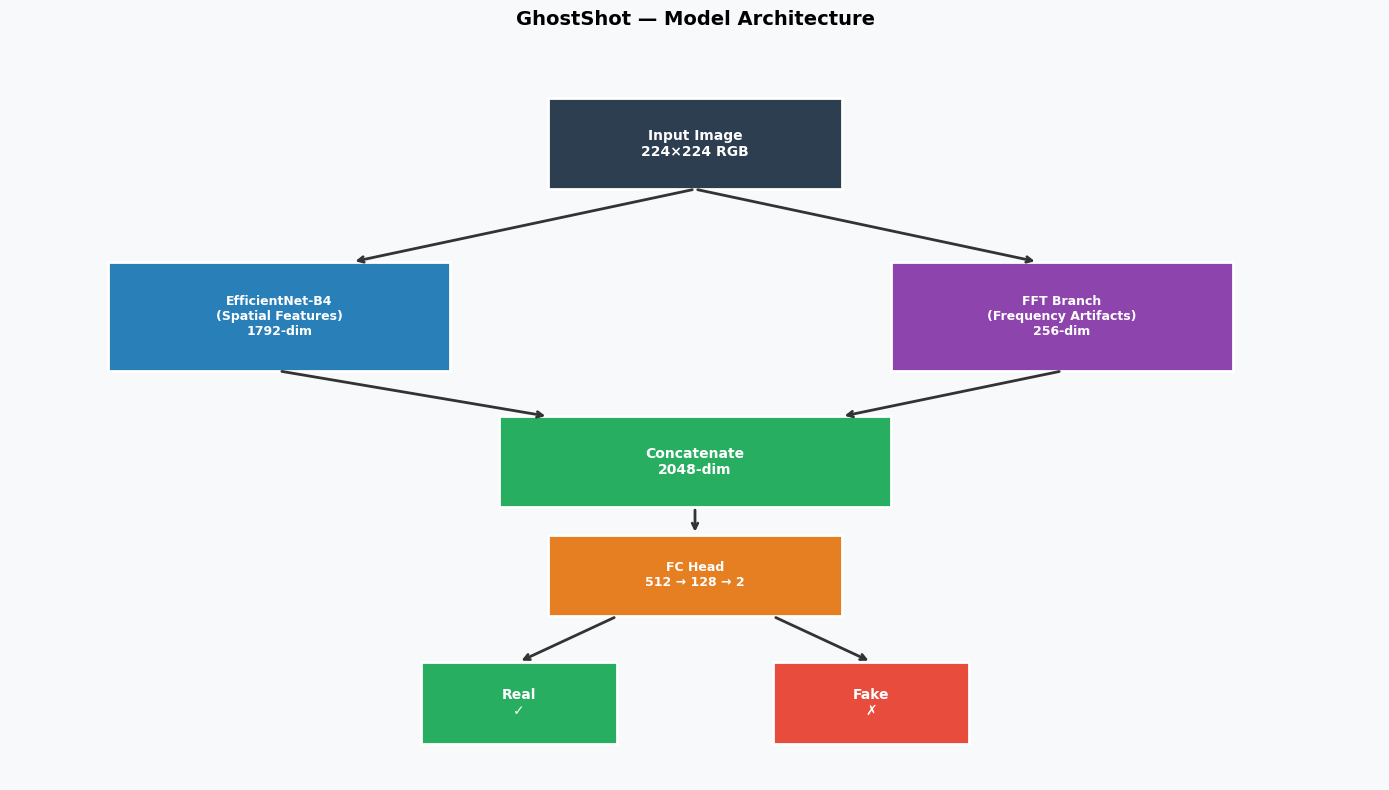

✅ Saved: model_architecture.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import os

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

def box(ax, x, y, w, h, color, text, fontsize=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, zorder=3, ec="white", lw=2))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white", zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="#333", lw=2))

# Input
box(ax, 5.5, 6.5, 3, 1, "#2c3e50", "Input Image\n224×224 RGB", 10)

# Two branches
box(ax, 1, 4.5, 3.5, 1.2, "#2980b9", "EfficientNet-B4\n(Spatial Features)\n1792-dim", 9)
box(ax, 9, 4.5, 3.5, 1.2, "#8e44ad", "FFT Branch\n(Frequency Artifacts)\n256-dim", 9)

# Concat
box(ax, 5, 3, 4, 1, "#27ae60", "Concatenate\n2048-dim", 10)

# Head
box(ax, 5.5, 1.8, 3, 0.9, "#e67e22", "FC Head\n512 → 128 → 2", 9)

# Output
box(ax, 4.2, 0.4, 2, 0.9, "#27ae60", "Real\n✓", 10)
box(ax, 7.8, 0.4, 2, 0.9, "#e74c3c", "Fake\n✗", 10)

# Arrows
arrow(ax, 7, 6.5, 3.5, 5.7)   # input → efficientnet
arrow(ax, 7, 6.5, 10.5, 5.7)  # input → fft
arrow(ax, 2.75, 4.5, 5.5, 4)  # efficientnet → concat
arrow(ax, 10.75, 4.5, 8.5, 4) # fft → concat
arrow(ax, 7, 3, 7, 2.7)       # concat → head
arrow(ax, 6.2, 1.8, 5.2, 1.3) # head → real
arrow(ax, 7.8, 1.8, 8.8, 1.3) # head → fake

ax.set_title("GhostShot — Model Architecture", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("results/figures/model_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: model_architecture.png")

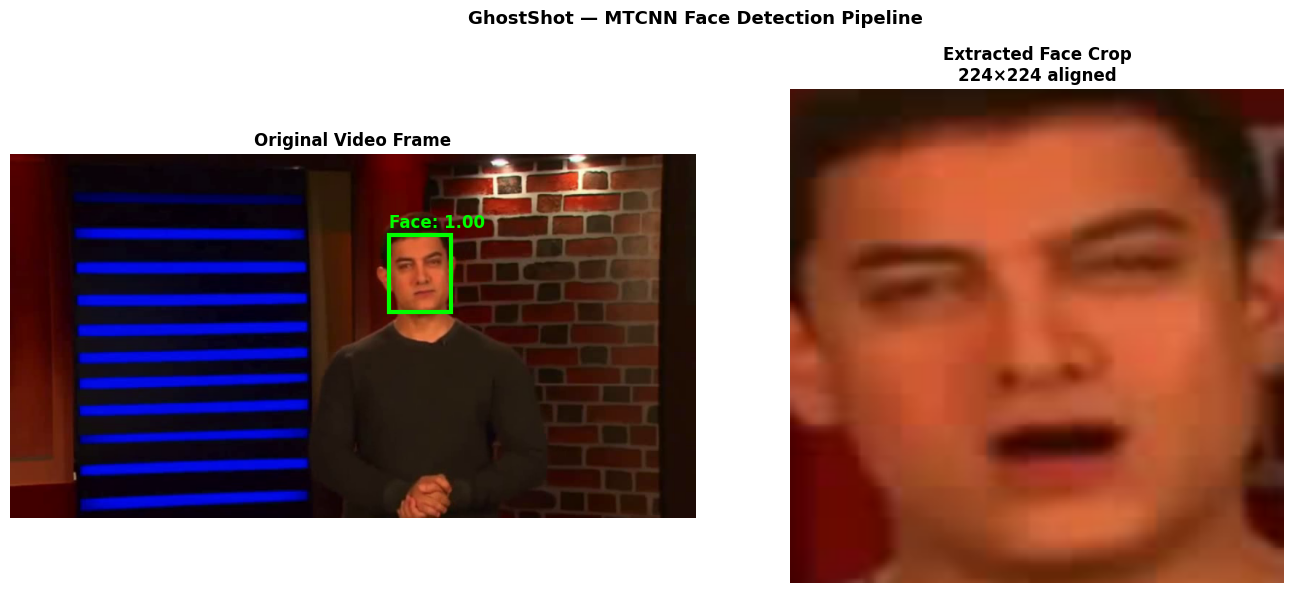

✅ Saved: mtcnn_detection.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from facenet_pytorch import MTCNN
import torch

# Load MTCNN
mtcnn = MTCNN(keep_all=True, device="cpu")

# Get a raw video frame
video_path = list(Path("data/raw/celebdf_v2/Celeb-real").glob("*.mp4"))[0]
cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_img   = Image.fromarray(frame_rgb)

# Detect faces
boxes, probs = mtcnn.detect(pil_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GhostShot — MTCNN Face Detection Pipeline", fontsize=13, fontweight="bold")

# Original frame with detection box
axes[0].imshow(frame_rgb)
axes[0].set_title("Original Video Frame", fontweight="bold")
axes[0].axis("off")
if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-10, f"Face: {prob:.2f}", color="lime",
                    fontsize=12, fontweight="bold")

# Cropped face
crop_path = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[0]
crop = cv2.imread(str(crop_path))
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
axes[1].imshow(crop)
axes[1].set_title("Extracted Face Crop\n224×224 aligned", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/mtcnn_detection.png", dpi=150)
plt.show()
print("✅ Saved: mtcnn_detection.png")

In [ ]:
from google.colab import files

new_figures = [
    "results/figures/model_architecture.png",
    "results/figures/mtcnn_detection.png",
]

for fig in new_figures:
    files.download(fig)
    print(f"✅ Downloaded: {fig.split('/')[-1]}")

FileNotFoundError: Cannot find file: results/figures/model_architecture.png

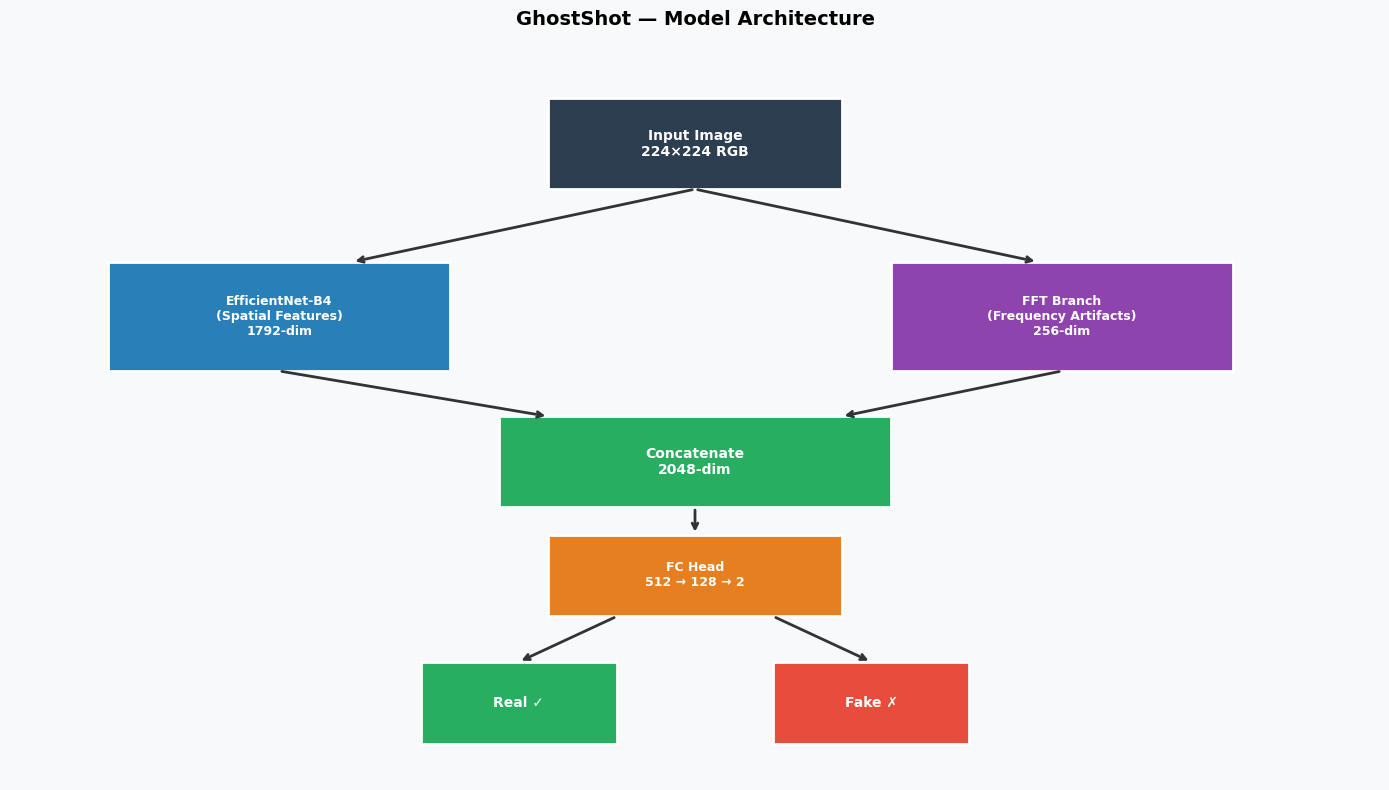

✅ Saved: model_architecture.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

# Model Architecture
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

def box(ax, x, y, w, h, color, text, fontsize=9):
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, zorder=3, ec="white", lw=2))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white", zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="#333", lw=2))

box(ax, 5.5, 6.5, 3, 1,   "#2c3e50", "Input Image\n224×224 RGB", 10)
box(ax, 1,   4.5, 3.5, 1.2, "#2980b9", "EfficientNet-B4\n(Spatial Features)\n1792-dim", 9)
box(ax, 9,   4.5, 3.5, 1.2, "#8e44ad", "FFT Branch\n(Frequency Artifacts)\n256-dim", 9)
box(ax, 5,   3,   4, 1,   "#27ae60", "Concatenate\n2048-dim", 10)
box(ax, 5.5, 1.8, 3, 0.9, "#e67e22", "FC Head\n512 → 128 → 2", 9)
box(ax, 4.2, 0.4, 2, 0.9, "#27ae60", "Real ✓", 10)
box(ax, 7.8, 0.4, 2, 0.9, "#e74c3c", "Fake ✗", 10)

arrow(ax, 7, 6.5, 3.5, 5.7)
arrow(ax, 7, 6.5, 10.5, 5.7)
arrow(ax, 2.75, 4.5, 5.5, 4)
arrow(ax, 10.75, 4.5, 8.5, 4)
arrow(ax, 7, 3, 7, 2.7)
arrow(ax, 6.2, 1.8, 5.2, 1.3)
arrow(ax, 7.8, 1.8, 8.8, 1.3)

ax.set_title("GhostShot — Model Architecture", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("results/figures/model_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: model_architecture.png")

# Download
from google.colab import files
files.download("results/figures/model_architecture.png")
print("✅ Downloaded!")

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from facenet_pytorch import MTCNN
import os

os.makedirs("results/figures", exist_ok=True)

mtcnn = MTCNN(keep_all=True, device="cpu")

video_path = list(Path("data/raw/celebdf_v2/Celeb-real").glob("*.mp4"))[0]
cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_img   = Image.fromarray(frame_rgb)
boxes, probs = mtcnn.detect(pil_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GhostShot — MTCNN Face Detection Pipeline", fontsize=13, fontweight="bold")

axes[0].imshow(frame_rgb)
axes[0].set_title("Original Video Frame", fontweight="bold")
axes[0].axis("off")
if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-10, f"Face: {prob:.2f}", color="lime",
                    fontsize=12, fontweight="bold")

crop_path = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[0]
crop = cv2.imread(str(crop_path))
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
axes[1].imshow(crop)
axes[1].set_title("Extracted Face Crop\n224×224 aligned", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/mtcnn_detection.png", dpi=150)
plt.show()

from google.colab import files
files.download("results/figures/mtcnn_detection.png")
print("✅ Downloaded!")

ModuleNotFoundError: No module named 'facenet_pytorch'

In [ ]:
!pip install -q facenet-pytorch

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.2.2 which is incompatible.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from facenet_pytorch import MTCNN
import os

os.makedirs("results/figures", exist_ok=True)

mtcnn = MTCNN(keep_all=True, device="cpu")

video_path = list(Path("data/raw/celebdf_v2/Celeb-real").glob("*.mp4"))[0]
cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_img   = Image.fromarray(frame_rgb)
boxes, probs = mtcnn.detect(pil_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GhostShot — MTCNN Face Detection Pipeline", fontsize=13, fontweight="bold")

axes[0].imshow(frame_rgb)
axes[0].set_title("Original Video Frame", fontweight="bold")
axes[0].axis("off")
if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-10, f"Face: {prob:.2f}", color="lime",
                    fontsize=12, fontweight="bold")

crop_path = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[0]
crop = cv2.imread(str(crop_path))
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
axes[1].imshow(crop)
axes[1].set_title("Extracted Face Crop\n224×224 aligned", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/mtcnn_detection.png", dpi=150)
plt.show()

from google.colab import files
files.download("results/figures/mtcnn_detection.png")
print("✅ Downloaded!")

ImportError: cannot import name 'is_directory' from 'PIL._util' (/usr/local/lib/python3.12/dist-packages/PIL/_util.py)

In [ ]:
!pip install -q "Pillow>=10.0.0" --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 49.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 12.2.0 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from facenet_pytorch import MTCNN
import os

os.makedirs("results/figures", exist_ok=True)

mtcnn = MTCNN(keep_all=True, device="cpu")

video_path = list(Path("data/raw/celebdf_v2/Celeb-real").glob("*.mp4"))[0]
cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_img   = Image.fromarray(frame_rgb)
boxes, probs = mtcnn.detect(pil_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GhostShot — MTCNN Face Detection Pipeline", fontsize=13, fontweight="bold")

axes[0].imshow(frame_rgb)
axes[0].set_title("Original Video Frame", fontweight="bold")
axes[0].axis("off")
if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-10, f"Face: {prob:.2f}", color="lime",
                    fontsize=12, fontweight="bold")

crop_path = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[0]
crop = cv2.imread(str(crop_path))
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
axes[1].imshow(crop)
axes[1].set_title("Extracted Face Crop\n224×224 aligned", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/mtcnn_detection.png", dpi=150)
plt.show()

from google.colab import files
files.download("results/figures/mtcnn_detection.png")
print("✅ Downloaded!")

IndexError: list index out of range

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from facenet_pytorch import MTCNN
import numpy as np
import os

os.makedirs("results/figures", exist_ok=True)

mtcnn = MTCNN(keep_all=True, device="cpu")

# Use existing face crop instead of video
crop_paths_real = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[:2]
crop_paths_fake = list(Path("data/processed/celebdf_fake/1").rglob("*.png"))[:1]

# Load a real crop as "frame"
frame = cv2.imread(str(crop_paths_real[0]))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_img   = Image.fromarray(frame_rgb)
boxes, probs = mtcnn.detect(pil_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GhostShot — MTCNN Face Detection Pipeline", fontsize=13, fontweight="bold")

axes[0].imshow(frame_rgb)
axes[0].set_title("Input Face Image", fontweight="bold")
axes[0].axis("off")
if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-5, f"Face: {prob:.2f}",
                    color="lime", fontsize=11, fontweight="bold")

# Show aligned crop
crop = cv2.imread(str(crop_paths_real[1]))
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
axes[1].imshow(crop)
axes[1].set_title("Extracted & Aligned\n224×224 Face Crop", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/mtcnn_detection.png", dpi=150)
plt.show()

from google.colab import files
files.download("results/figures/mtcnn_detection.png")
print("✅ Downloaded!")

IndexError: list index out of range

In [ ]:
import os, sys

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive_old", force_remount=True)

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

DRIVE_WITH_DATA = "/content/drive_old/MyDrive/ghostshot"
links = {
    f"{DRIVE_WITH_DATA}/data/raw":            "/content/ghostshot/data/raw",
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"Ready. Device = {device}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/ghostshot'

In [ ]:
import os, sys

!git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive_old", force_remount=True)

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

DRIVE_WITH_DATA = "/content/drive_old/MyDrive/ghostshot"
links = {
    f"{DRIVE_WITH_DATA}/data/raw":            "/content/ghostshot/data/raw",
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"Ready. Device = {device}")

Cloning into '/content/ghostshot'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 63 (delta 19), reused 51 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 751.52 KiB | 9.51 MiB/s, done.
Resolving deltas: 100% (19/19), done.
Mounted at /content/drive_old
[seed] All random seeds set to 42
[device] Using configured device: cuda
✅ raw
✅ processed
✅ attack_samples
✅ checkpoints
✅ results
Ready. Device = cuda


In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  facenet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 10.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.2.2 which is incompatible.


Found 2 real crops


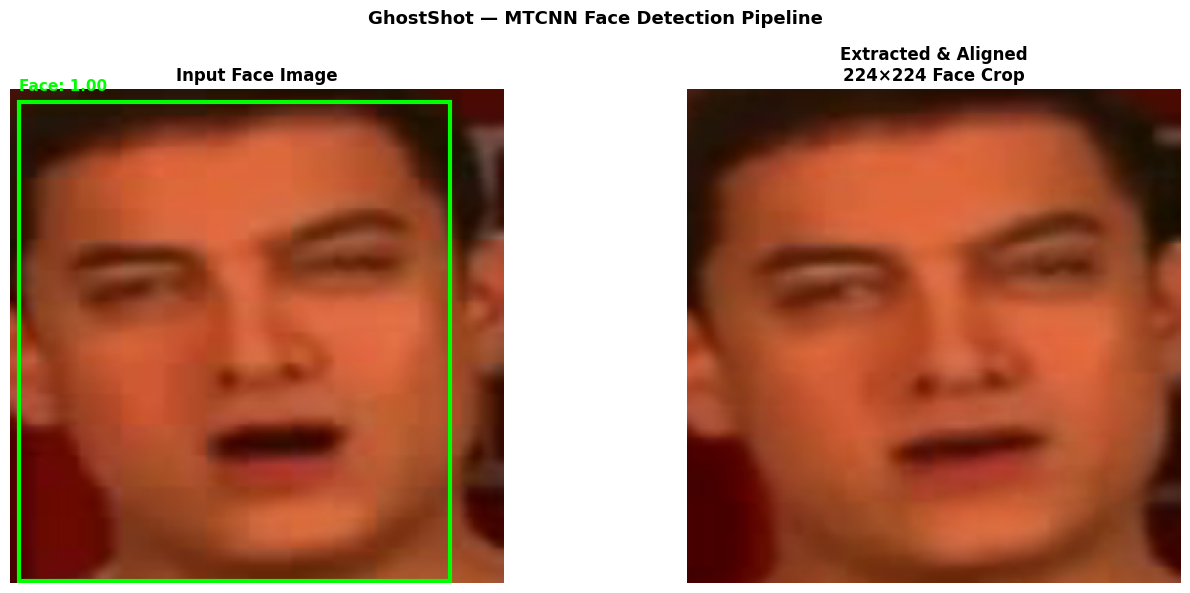

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!


In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from facenet_pytorch import MTCNN
import os

os.makedirs("results/figures", exist_ok=True)

mtcnn = MTCNN(keep_all=True, device="cpu")

# Use existing face crops
crop_paths_real = list(Path("data/processed/celebdf_real/0").rglob("*.png"))[:2]
print(f"Found {len(crop_paths_real)} real crops")

frame     = cv2.imread(str(crop_paths_real[0]))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
pil_img   = Image.fromarray(frame_rgb)
boxes, probs = mtcnn.detect(pil_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GhostShot — MTCNN Face Detection Pipeline", fontsize=13, fontweight="bold")

axes[0].imshow(frame_rgb)
axes[0].set_title("Input Face Image", fontweight="bold")
axes[0].axis("off")
if boxes is not None:
    for box, prob in zip(boxes, probs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor="lime", facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-5, f"Face: {prob:.2f}",
                    color="lime", fontsize=11, fontweight="bold")

crop = cv2.imread(str(crop_paths_real[1]))
crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
axes[1].imshow(crop)
axes[1].set_title("Extracted & Aligned\n224×224 Face Crop", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/mtcnn_detection.png", dpi=150)
plt.show()

from google.colab import files
files.download("results/figures/mtcnn_detection.png")
print("✅ Downloaded!")

In [ ]:
import os, sys

if not os.path.exists("/content/ghostshot"):
    !git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive")
drive.mount("/content/drive_old", force_remount=False)

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

# Find drive with data
DRIVE_WITH_DATA = None
for d in ["/content/drive", "/content/drive_old"]:
    p = Path(f"{d}/MyDrive/ghostshot/data/processed")
    try:
        if list(p.iterdir()):
            DRIVE_WITH_DATA = f"{d}/MyDrive/ghostshot"
            print(f"✅ Data found in: {d}")
            break
    except: pass

links = {
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"Ready. Device = {device}")

Cloning into '/content/ghostshot'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 71 (delta 21), reused 59 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 756.18 KiB | 2.70 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Mounted at /content/drive
Mounted at /content/drive_old
[seed] All random seeds set to 42
[device] Using configured device: cuda
✅ Data found in: /content/drive_old
✅ processed
✅ attack_samples
✅ checkpoints
✅ results
Ready. Device = cuda


In [ ]:
import pandas as pd
from pathlib import Path

train_df = pd.read_csv("data/processed/splits/train.csv")
val_df   = pd.read_csv("data/processed/splits/val.csv")
test_df  = pd.read_csv("data/processed/splits/test.csv")

print("=" * 50)
print("  GhostShot — Dataset Statistics")
print("=" * 50)

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    real = (df["label"] == 0).sum()
    fake = (df["label"] == 1).sum()
    print(f"\n{name} set ({len(df)} videos):")
    print(f"  Real videos: {real}")
    print(f"  Fake videos: {fake}")
    print(f"  Total crops: {df['n_crops'].sum():,}")
    print(f"  Real crops : {df[df['label']==0]['n_crops'].sum():,}")
    print(f"  Fake crops : {df[df['label']==1]['n_crops'].sum():,}")

print("\n── Total Dataset ─────────────────────────────")
all_df = pd.concat([train_df, val_df, test_df])
print(f"  Total videos    : {len(all_df):,}")
print(f"  Total real crops: {all_df[all_df['label']==0]['n_crops'].sum():,}")
print(f"  Total fake crops: {all_df[all_df['label']==1]['n_crops'].sum():,}")
print(f"  Grand total     : {all_df['n_crops'].sum():,}")

  GhostShot — Dataset Statistics

Train set (2091 videos):
  Real videos: 514
  Fake videos: 1577
  Total crops: 66,597
  Real crops : 16,343
  Fake crops : 50,254

Val set (448 videos):
  Real videos: 106
  Fake videos: 342
  Total crops: 14,299
  Real crops : 3,380
  Fake crops : 10,919

Test set (449 videos):
  Real videos: 117
  Fake videos: 332
  Total crops: 14,320
  Real crops : 3,740
  Fake crops : 10,580

── Total Dataset ─────────────────────────────
  Total videos    : 2,988
  Total real crops: 23,463
  Total fake crops: 71,753
  Grand total     : 95,216


In [ ]:
import os, sys

!git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive_old", force_remount=True)

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

DRIVE_WITH_DATA = "/content/drive_old/MyDrive/ghostshot"
links = {
    f"{DRIVE_WITH_DATA}/data/raw":            "/content/ghostshot/data/raw",
    f"{DRIVE_WITH_DATA}/data/processed":      "/content/ghostshot/data/processed",
    f"{DRIVE_WITH_DATA}/data/attack_samples": "/content/ghostshot/data/attack_samples",
    f"{DRIVE_WITH_DATA}/models/checkpoints":  "/content/ghostshot/models/checkpoints",
    f"{DRIVE_WITH_DATA}/results":             "/content/ghostshot/results",
}
for drive_path, local_link in links.items():
    Path(local_link).parent.mkdir(parents=True, exist_ok=True)
    if os.path.islink(local_link): os.unlink(local_link)
    elif os.path.isdir(local_link): os.rmdir(local_link)
    os.symlink(drive_path, local_link)
    print(f"✅ {Path(local_link).name}")

print(f"Ready. Device = {device}")

Cloning into '/content/ghostshot'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 71 (delta 21), reused 59 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 756.18 KiB | 16.09 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Mounted at /content/drive_old
[seed] All random seeds set to 42
[device] Using configured device: cuda
✅ raw
✅ processed
✅ attack_samples
✅ checkpoints
✅ results
Ready. Device = cuda


In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.8 MB/s eta 0:00:00


In [ ]:
import torch
import glob
from src.models.classifier import GhostShotDetector

ckpts     = sorted(glob.glob("models/checkpoints/ghostshot_best_*.pt"))
best_ckpt = ckpts[-1]
print(f"Loading: {best_ckpt}")

ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)

model = GhostShotDetector(
    num_classes    = cfg["data"]["num_classes"],
    pretrained     = False,
    use_fft_branch = cfg["model"]["use_fft_branch"],
    dropout        = cfg["model"]["dropout"],
).to(device)

model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"✅ Loaded epoch {ckpt['epoch']} | Val AUC {ckpt['val_auc']:.4f}")

Loading: models/checkpoints/ghostshot_best_epoch10_auc0.8616.pt
✅ Loaded epoch 10 | Val AUC 0.8616


🔍 Testing on REAL face...


/tmp/ipykernel_8294/2739185657.py:70: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8294/2739185657.py:71: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("results/figures/demo_prediction.png", dpi=150, facecolor="#1a1a2e")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


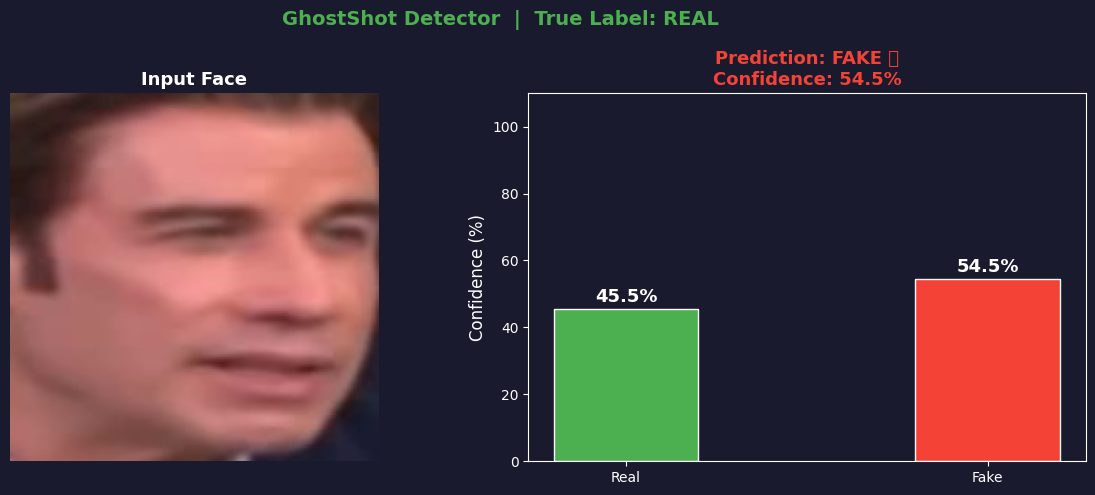


  GhostShot Prediction
  True label : REAL
  Prediction : FAKE ❌
  Real prob  : 45.5%
  Fake prob  : 54.5%


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
import random

random.seed(42)

transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def predict_and_show(img_path, true_label):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(probs.argmax())

    label_names = {0: "REAL", 1: "FAKE"}
    confidence  = probs[pred] * 100
    correct     = pred == true_label

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor("#1a1a2e")

    axes[0].imshow(img_resized)
    axes[0].set_title("Input Face", fontsize=13, color="white", fontweight="bold")
    axes[0].axis("off")

    colors = ["#4CAF50", "#f44336"]
    bars = axes[1].bar(["Real", "Fake"], probs * 100,
                       color=colors, width=0.4, edgecolor="white")
    axes[1].set_ylim(0, 110)
    axes[1].set_ylabel("Confidence (%)", color="white", fontsize=12)
    axes[1].set_facecolor("#1a1a2e")
    axes[1].tick_params(colors="white")
    for spine in axes[1].spines.values():
        spine.set_edgecolor("white")

    for bar, val in zip(bars, probs * 100):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 2,
                    f"{val:.1f}%", ha="center",
                    fontsize=13, fontweight="bold", color="white")

    result_color = "#4CAF50" if correct else "#f44336"
    result_icon  = "✅" if correct else "❌"
    axes[1].set_title(
        f"Prediction: {label_names[pred]} {result_icon}\nConfidence: {confidence:.1f}%",
        fontsize=13, color=result_color, fontweight="bold"
    )

    true_color = "#4CAF50" if true_label == 0 else "#f44336"
    fig.suptitle(
        f"GhostShot Detector  |  True Label: {label_names[true_label]}",
        fontsize=14, fontweight="bold", color=true_color
    )

    plt.tight_layout()
    plt.savefig("results/figures/demo_prediction.png", dpi=150, facecolor="#1a1a2e")
    plt.show()

    print(f"\n{'='*40}")
    print(f"  GhostShot Prediction")
    print(f"{'='*40}")
    print(f"  True label : {label_names[true_label]}")
    print(f"  Prediction : {label_names[pred]} {result_icon}")
    print(f"  Real prob  : {probs[0]*100:.1f}%")
    print(f"  Fake prob  : {probs[1]*100:.1f}%")
    print(f"{'='*40}")

# Demo on REAL face
print("🔍 Testing on REAL face...")
real_imgs = list(Path("data/processed/celebdf_real/0").rglob("*.png"))
predict_and_show(str(random.choice(real_imgs)), true_label=0)

In [ ]:
# Test 5 real images and 5 fake images, show summary
print("Testing 5 REAL images:")
real_imgs = list(Path("data/processed/celebdf_real/0").rglob("*.png"))
correct_real = 0
for img_path in random.sample(real_imgs, 5):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(probs.argmax())
    status = "✅" if pred == 0 else "❌"
    if pred == 0: correct_real += 1
    print(f"  {status} Pred: {'Real' if pred==0 else 'Fake'} (Real={probs[0]*100:.1f}%, Fake={probs[1]*100:.1f}%)")

print(f"\nReal accuracy: {correct_real}/5")

print("\nTesting 5 FAKE images:")
fake_imgs = list(Path("data/processed/celebdf_fake/1").rglob("*.png"))
correct_fake = 0
for img_path in random.sample(fake_imgs, 5):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    tensor = transform(image=img_resized)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred   = int(probs.argmax())
    status = "✅" if pred == 1 else "❌"
    if pred == 1: correct_fake += 1
    print(f"  {status} Pred: {'Real' if pred==0 else 'Fake'} (Real={probs[0]*100:.1f}%, Fake={probs[1]*100:.1f}%)")

print(f"\nFake accuracy: {correct_fake}/5")

Testing 5 REAL images:
  ✅ Pred: Real (Real=61.1%, Fake=38.9%)
  ✅ Pred: Real (Real=55.0%, Fake=45.0%)
  ✅ Pred: Real (Real=68.5%, Fake=31.5%)
  ✅ Pred: Real (Real=59.6%, Fake=40.4%)
  ❌ Pred: Fake (Real=45.0%, Fake=55.0%)

Real accuracy: 4/5

Testing 5 FAKE images:
  ✅ Pred: Fake (Real=22.1%, Fake=77.9%)
  ✅ Pred: Fake (Real=32.7%, Fake=67.3%)
  ✅ Pred: Fake (Real=24.3%, Fake=75.7%)
  ✅ Pred: Fake (Real=22.5%, Fake=77.5%)
  ✅ Pred: Fake (Real=42.9%, Fake=57.1%)

Fake accuracy: 5/5


In [ ]:
import shutil
from pathlib import Path

# Delete raw videos (saves ~9GB)
raw_dir = Path("/content/drive_old/MyDrive/ghostshot/data/raw")
if raw_dir.exists():
    shutil.rmtree(raw_dir)
    print("✅ Raw videos deleted — freed ~9GB!")

# Keep only best checkpoint
ckpt_dir = Path("/content/drive_old/MyDrive/ghostshot/models/checkpoints")
best = "ghostshot_best_epoch10_auc0.8616.pt"
for ckpt in ckpt_dir.glob("*.pt"):
    if ckpt.name != best:
        ckpt.unlink()
        print(f"Deleted: {ckpt.name}")
print("✅ Kept only best checkpoint!")

✅ Kept only best checkpoint!


In [ ]:
!du -sh /content/drive_old/MyDrive/ghostshot/*

du: cannot access '/content/drive_old/MyDrive/ghostshot/*': No such file or directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive"

'Colab Notebooks'   ghostshot   TP1.pdf


In [ ]:
!du -sh "/content/drive/MyDrive"

15G	/content/drive/MyDrive


In [ ]:
!du -h --max-depth=1 "/content/drive/MyDrive" | sort -hr | head -20

15G	/content/drive/MyDrive/ghostshot
15G	/content/drive/MyDrive
7.9M	/content/drive/MyDrive/Colab Notebooks
